<a href="https://colab.research.google.com/github/rudransh2214/JECRC/blob/main/AIML_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arjunsinghgangwar/ncrb-crime-data-2014")

print("Path to dataset files:", path)

100%|██████████| 64.5k/64.5k [00:00<00:00, 19.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/arjunsinghgangwar/ncrb-crime-data-2014/versions/1


NCRB CRIME DATA 2014 - MACHINE LEARNING PROJECT

Using Colab cache for faster access to the 'ncrb-crime-data-2014' dataset.
Dataset downloaded successfully!
Dataset path: /kaggle/input/ncrb-crime-data-2014

CSV files found:
1. /kaggle/input/ncrb-crime-data-2014/All_State_NCRB_Crime_Data_2014.csv

Searching for a dataset containing a rape-related column...

Selected file:
/kaggle/input/ncrb-crime-data-2014/All_State_NCRB_Crime_Data_2014.csv

Prediction target:
Rape

Dataset shape:
(838, 91)

First five rows:
       States/UTs          District  Year  Murder  Attempt to commit Murder  \
0  Andhra Pradesh         Anantapur  2014     134                       171   
1  Andhra Pradesh          Chittoor  2014      84                       170   
2  Andhra Pradesh          Cuddapah  2014      80                       162   
3  Andhra Pradesh     East Godavari  2014      64                        84   
4  Andhra Pradesh  Guntakal Railway  2014      14                         4   

   Culpable 

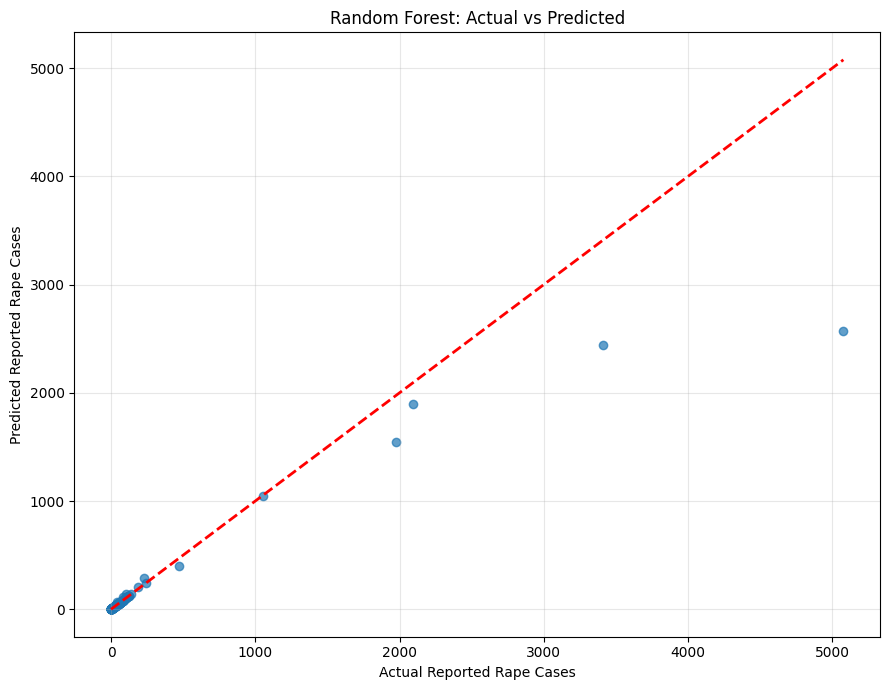


FEATURE IMPORTANCE
                                              Feature  Importance
8                           Rape other than Custodial    0.320561
10                                        Rape_Others    0.179017
70                Cruelty by Husband or his Relatives    0.057364
59  Assault on Women with intent to outrage her Mo...    0.030916
87                        Total Cognizable IPC crimes    0.026102
17                                   Other Kidnapping    0.025762
53                                              Arson    0.023061
2                            Attempt to commit Murder    0.021819
3           Culpable Homicide not amounting to Murder    0.019209
24                      Criminal Trespass or Burglary    0.017505
23                         Criminal Trespass/Burglary    0.017197
26                                              Theft    0.017195
1                                              Murder    0.015351
42                                           Cheating   

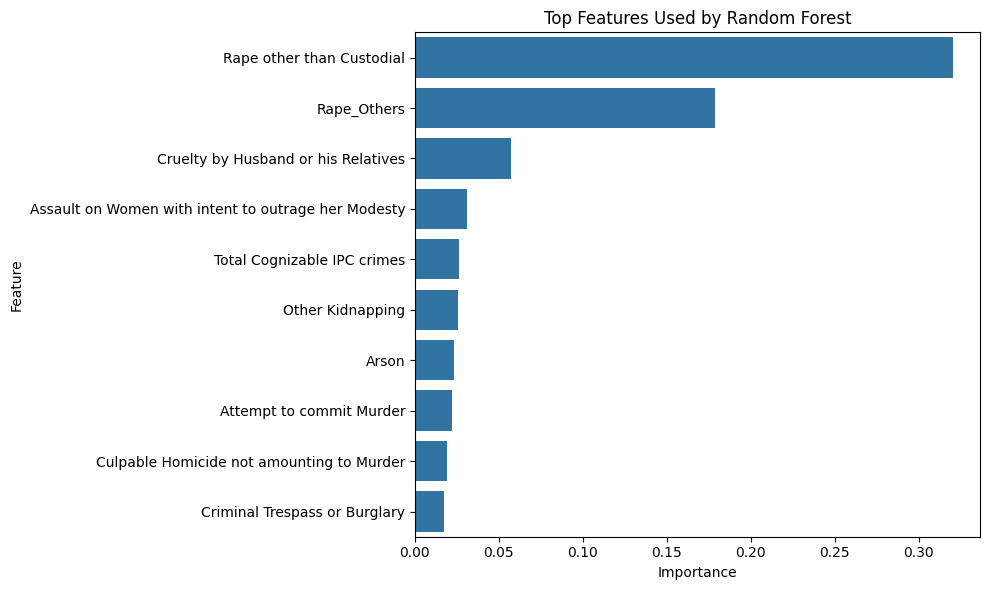


MODEL SAVED
Saved model: ncrb_rape_prediction_model.pkl

Saved model loaded successfully!

EXAMPLE PREDICTION
Actual reported rape cases    : 41
Predicted reported rape cases : 41.12

PROJECT COMPLETE

Prediction target:
Number of reported rape cases

Models trained:
1. Linear Regression
2. Random Forest Regression

Random Forest performance:
MAE : 26.29
RMSE: 210.48
R²  : 0.8346

The trained Random Forest model has been saved as:
ncrb_rape_prediction_model.pkl

Done!


In [2]:

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

print("=" * 70)
print("NCRB CRIME DATA 2014 - MACHINE LEARNING PROJECT")
print("=" * 70)




print("\nDownloading Kaggle dataset...")

path = kagglehub.dataset_download(
    "arjunsinghgangwar/ncrb-crime-data-2014"
)

print("Dataset downloaded successfully!")
print("Dataset path:", path)



csv_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("\nCSV files found:")

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV files were found in the downloaded dataset."
    )

for i, file in enumerate(csv_files):
    print(f"{i + 1}. {file}")


print("\nSearching for a dataset containing a rape-related column...")

selected_file = None
target_column = None

for file in csv_files:

    try:
        temp_df = pd.read_csv(file)

        for col in temp_df.columns:

            col_clean = (
                str(col)
                .lower()
                .strip()
                .replace("_", " ")
                .replace("-", " ")
            )

            # Look for columns containing "rape"
            if "rape" in col_clean:

                # Avoid columns that appear to be percentages/rates
                # when a raw count column may be available.
                if (
                    "rate" not in col_clean
                    and "percent" not in col_clean
                    and "%" not in col_clean
                ):
                    selected_file = file
                    target_column = col
                    break

        if selected_file is not None:
            break

    except Exception as e:
        print("Could not read:", file)
        print("Error:", e)

if selected_file is None:

    print("\nNo rape-related target column was automatically found.")

    print("\nPlease inspect the available files and columns:")

    for file in csv_files:
        try:
            temp_df = pd.read_csv(file)

            print("\nFile:", file)
            print("Columns:")

            for col in temp_df.columns:
                print("  -", col)

        except:
            pass

    raise ValueError(
        "\nThe program could not automatically identify a rape cases column."
    )


print("\nSelected file:")
print(selected_file)

print("\nPrediction target:")
print(target_column)



df = pd.read_csv(selected_file)

print("\nDataset shape:")
print(df.shape)

print("\nFirst five rows:")
print(df.head())



print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)



duplicates = df.duplicated().sum()

print("\nDuplicate rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")



df[target_column] = (
    df[target_column]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df[target_column] = pd.to_numeric(
    df[target_column],
    errors="coerce"
)


before = len(df)

df = df.dropna(
    subset=[target_column]
).copy()

after = len(df)

print("\nRows removed because target was missing:", before - after)


print("\n" + "=" * 70)
print("TARGET VARIABLE")
print("=" * 70)

print("Target:", target_column)

print("\nTarget statistics:")

print(df[target_column].describe())


# Select only numerical columns.
numeric_columns = df.select_dtypes(
    include=["number"]
).columns.tolist()

print("\nNumerical columns:")
print(numeric_columns)


y = df[target_column].copy()

X = df[numeric_columns].copy()


# Remove target from X
if target_column in X.columns:
    X = X.drop(columns=[target_column])



columns_to_remove = []

for col in X.columns:

    col_lower = str(col).lower().strip()

    if (
        col_lower in ["id", "s.no", "sno", "serial no", "serial number"]
        or "serial" in col_lower
    ):
        columns_to_remove.append(col)


if len(columns_to_remove) > 0:

    print("\nRemoving ID/serial columns:")
    print(columns_to_remove)

    X = X.drop(
        columns=columns_to_remove,
        errors="ignore"
    )


# ============================================================
# 15. CHECK NUMBER OF FEATURES
# ============================================================

print("\nFeatures used by the model:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])


if X.shape[1] == 0:

    raise ValueError(
        "No numerical features were available after preprocessing."
    )


# ============================================================
# 16. REMOVE EXTREME / INVALID TARGET VALUES
# ============================================================

# Crime counts should not normally be negative.

negative_targets = (y < 0).sum()

if negative_targets > 0:

    print(
        "\nRemoving",
        negative_targets,
        "rows with negative target values."
    )

    valid_rows = y >= 0

    X = X.loc[valid_rows]
    y = y.loc[valid_rows]


# ============================================================
# 17. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))


# ============================================================
# 18. CREATE PREPROCESSING PIPELINE
# ============================================================

# Missing numerical values will be replaced by the median.

preprocessor = SimpleImputer(
    strategy="median"
)


linear_model = Pipeline(
    steps=[
        ("imputer", preprocessor),
        ("model", LinearRegression())
    ]
)


print("\nTraining Linear Regression...")

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)


random_forest_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


print("Training Random Forest...")

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_test
)


def evaluate_model(
    model_name,
    actual,
    predictions
):

    mae = mean_absolute_error(
        actual,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predictions
        )
    )

    r2 = r2_score(
        actual,
        predictions
    )

    print("\n" + "-" * 50)
    print(model_name)
    print("-" * 50)

    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R²  :", round(r2, 4))

    return mae, rmse, r2


linear_mae, linear_rmse, linear_r2 = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)


rf_mae, rf_rmse, rf_r2 = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions
)


results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest"
    ],

    "MAE": [
        linear_mae,
        rf_mae
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse
    ],

    "R2": [
        linear_r2,
        rf_r2
    ]
})


print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(results)


comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Linear Regression Prediction":
        linear_predictions,

    "Random Forest Prediction":
        rf_predictions

})


print("\n" + "=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)

print(
    comparison.head(15)
)


plt.figure(
    figsize=(9, 7)
)

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.7
)

min_value = min(
    y_test.min(),
    rf_predictions.min()
)

max_value = max(
    y_test.max(),
    rf_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Actual Reported Rape Cases"
)

plt.ylabel(
    "Predicted Reported Rape Cases"
)

plt.title(
    "Random Forest: Actual vs Predicted"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 26. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# Get the actual Random Forest model
rf = random_forest_model.named_steps["model"]

importances = rf.feature_importances_

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": importances

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


print("\n" + "=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

print(
    feature_importance.head(15)
)


# ============================================================
# 27. PLOT FEATURE IMPORTANCE
# ============================================================

top_features = feature_importance.head(10)

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features Used by Random Forest"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()


# ============================================================
# 28. SAVE THE MODEL
# ============================================================

model_filename = "ncrb_rape_prediction_model.pkl"

joblib.dump(
    random_forest_model,
    model_filename
)

print("\n" + "=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(
    "Saved model:",
    model_filename
)


# ============================================================
# 29. LOAD THE SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    model_filename
)

print("\nSaved model loaded successfully!")


# ============================================================
# 30. EXAMPLE PREDICTION
# ============================================================

# Take one row from the test data and predict it.

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(
    sample
)[0]

actual = y_test.iloc[0]

print("\n" + "=" * 70)
print("EXAMPLE PREDICTION")
print("=" * 70)

print(
    "Actual reported rape cases    :",
    round(actual, 2)
)

print(
    "Predicted reported rape cases :",
    round(prediction, 2)
)


# ============================================================
# 31. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PROJECT COMPLETE")
print("=" * 70)

print(
    "\nPrediction target:"
)

print(
    "Number of reported rape cases"
)

print(
    "\nModels trained:"
)

print(
    "1. Linear Regression"
)

print(
    "2. Random Forest Regression"
)

print(
    "\nRandom Forest performance:"
)

print(
    "MAE :",
    round(rf_mae, 2)
)

print(
    "RMSE:",
    round(rf_rmse, 2)
)

print(
    "R²  :",
    round(rf_r2, 4)
)

print(
    "\nThe trained Random Forest model has been saved as:"
)

print(
    model_filename
)

print("\nDone!")


In [4]:
pip install gradio -qq

## Model Deployment with Gradio

This section creates a simple web interface using Gradio to interact with the trained Random Forest model. You can adjust the values of the top 5 most important features, and the model will predict the number of reported rape cases. For features not exposed in the interface, their median values from the training data are used.


In [3]:
import gradio as gr

# Calculate median values for all features from the training set
# This will be used for features not directly exposed in the Gradio interface
feature_medians = X_train.median()

# Identify the top 5 features from the feature_importance DataFrame
top_5_features = feature_importance['Feature'].head(5).tolist()

# Define the prediction function for Gradio
def predict_rape_cases(
    feature1_val,
    feature2_val,
    feature3_val,
    feature4_val,
    feature5_val
):
    # Create a DataFrame for the input sample
    # Initialize with median values for all features
    input_data = pd.DataFrame(columns=X.columns)
    sample_row = feature_medians.copy()

    # Update values for the top 5 features based on user input
    sample_row[top_5_features[0]] = feature1_val
    sample_row[top_5_features[1]] = feature2_val
    sample_row[top_5_features[2]] = feature3_val
    sample_row[top_5_features[3]] = feature4_val
    sample_row[top_5_features[4]] = feature5_val

    # Append the sample row to the input_data DataFrame, ensuring correct column order
    input_data.loc[0] = sample_row

    # Make prediction using the loaded model
    prediction = loaded_model.predict(input_data)[0]

    return round(prediction, 2)

# Create Gradio interface inputs for the top 5 features
# Set reasonable min/max based on feature distribution in X_train for better UX
inputs = [
    gr.Number(
        label=top_5_features[0],
        value=feature_medians[top_5_features[0]],
        minimum=X_train[top_5_features[0]].min(),
        maximum=X_train[top_5_features[0]].max()
    ),
    gr.Number(
        label=top_5_features[1],
        value=feature_medians[top_5_features[1]],
        minimum=X_train[top_5_features[1]].min(),
        maximum=X_train[top_5_features[1]].max()
    ),
    gr.Number(
        label=top_5_features[2],
        value=feature_medians[top_5_features[2]],
        minimum=X_train[top_5_features[2]].min(),
        maximum=X_train[top_5_features[2]].max()
    ),
    gr.Number(
        label=top_5_features[3],
        value=feature_medians[top_5_features[3]],
        minimum=X_train[top_5_features[3]].min(),
        maximum=X_train[top_5_features[3]].max()
    ),
    gr.Number(
        label=top_5_features[4],
        value=feature_medians[top_5_features[4]],
        minimum=X_train[top_5_features[4]].min(),
        maximum=X_train[top_5_features[4]].max()
    )
]

# Create the Gradio interface
iface = gr.Interface(
    fn=predict_rape_cases,
    inputs=inputs,
    outputs=gr.Number(label="Predicted Reported Rape Cases"),
    title="NCRB Rape Cases Prediction",
    description="Adjust the top 5 crime-related features to predict the number of reported rape cases. Other features are set to their median values."
)

# Launch the interface
print("\nLaunching Gradio interface...")
iface.launch(share=True)

# Display benchmark scores
print("\n" + "=" * 70)
print("MODEL BENCHMARK SCORES (Random Forest)")
print("=" * 70)
print(f"Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.2f}")
print(f"R-squared (R²): {rf_r2:.4f}")
print("\nNote: For regression models, MAE, RMSE, and R-squared are used instead of accuracy.")



Launching Gradio interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d84dc9a6ab77f08754.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



MODEL BENCHMARK SCORES (Random Forest)
Mean Absolute Error (MAE): 26.29
Root Mean Squared Error (RMSE): 210.48
R-squared (R²): 0.8346

Note: For regression models, MAE, RMSE, and R-squared are used instead of accuracy.
